In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [5]:
df = pd.read_csv("eBay1.csv")
df.head(10)

,Timestamp,age,Gender,Purchase_Frequency,Purchase_Categories,Personalized_Recommendation_Frequency,Browsing_Frequency,Product_Search_Method,Search_Result_Exploration,Customer_Reviews_Importance,...,Review_Left,Review_Reliability,Review_Helpfulness,Personalized_Recommendation_Frequency,Recommendation_Helpfulness,Rating_Accuracy,Shopping_Satisfaction,Service_Appreciation,Improvement_Areas,transaction
0,2023/06/07 11:44:55 AM GMT+5:30,32,Prefer not to say,Multiple times a week,Groceries and Gourmet Food;Home and Kitchen,Sometimes,Rarely,categories,Multiple pages,5,...,Yes,Never,Yes,5,Yes,1,1,Customer service,.,819284
1,2023/06/07 9:28:09 AM GMT+5:30,47,Female,Multiple times a week,Groceries and Gourmet Food;Beauty and Personal...,No,Few times a month,NaN,First page,5,...,Yes,Never,Sometimes,2,Yes,4,4,User-friendly website/app interface,Shipping speed and reliability,599249
2,2023/06/05 10:09:03 PM GMT+5:30,50,Female,Once a month,Groceries and Gourmet Food;Beauty and Personal...,Sometimes,Multiple times a day,categories,Multiple pages,1,...,Yes,Rarely,Sometimes,1,Sometimes,4,2,Customer service,Reducing packaging waste,432245
3,2023/06/07 5:58:12 PM GMT+5:30,6,Others,Once a month,Groceries and Gourmet Food;Beauty and Personal...,No,Rarely,others,Multiple pages,1,...,No,Heavily,No,2,Yes,4,4,Product recommendations,Irrelevant product suggestions,476517
4,2023/06/07 11:46:52 AM GMT+5:30,61,Male,Once a week,Groceries and Gourmet Food;Clothing and Fashion,Yes,Rarely,NaN,Multiple pages,5,...,No,Never,Yes,2,No,3,2,Product recommendations,Shipping speed and reliability,894659
5,2023/06/08 5:49:56 PM GMT+5:30,14,Prefer not to say,Few times a month,Clothing and Fashion,Sometimes,Few times a month,NaN,First page,3,...,Yes,Rarely,Yes,1,No,5,1,.,.,609504
6,2023/06/09 2:36:09 PM GMT+5:30,31,Female,Once a week,Clothing and Fashion;others,Yes,Few times a month,categories,First page,3,...,Yes,Rarely,No,4,No,5,3,.,Product quality and accuracy,502692
7,2023/06/11 9:15:38 PM GMT+5:30,54,Female,Few times a month,Clothing and Fashion;Home and Kitchen;others,Yes,Few times a month,Keyword,Multiple pages,3,...,Yes,Occasionally,No,4,Yes,2,2,Product recommendations,Nothing,836059
8,2023/06/06 6:51:13 PM GMT+5:30,10,Prefer not to say,Few times a month,Clothing and Fashion;Home and Kitchen,Yes,Few times a month,NaN,Multiple pages,2,...,No,Moderately,Sometimes,3,Sometimes,5,1,Competitive prices,Shipping speed and reliability,795705
9,2023/06/08 5:55:54 PM GMT+5:30,52,Prefer not to say,Multiple times a week,Beauty and Personal Care;Clothing and Fashion;...,Sometimes,Few times a month,Keyword,First page,1,...,Yes,Occasionally,No,1,Sometimes,5,4,Customer service,User interface,406580


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 24 columns):
 #   Column                                  Non-Null Count  Dtype 
---  ------                                  --------------  ----- 
 0   Timestamp                               800 non-null    object
 1   age                                     800 non-null    int64 
 2   Gender                                  800 non-null    object
 3   Purchase_Frequency                      800 non-null    object
 4   Purchase_Categories                     800 non-null    object
 5   Personalized_Recommendation_Frequency   800 non-null    object
 6   Browsing_Frequency                      800 non-null    object
 7   Product_Search_Method                   639 non-null    object
 8   Search_Result_Exploration               800 non-null    object
 9   Customer_Reviews_Importance             800 non-null    int64 
 10  Add_to_Cart_Browsing                    800 non-null    object
 11  Cart_C

# Task 1: Data Cleaning and Preparation 

### Remove duplicate or inconsistent survey responses.
### Standardize categorical/numerical entries (e.g., frequency levels, gender,recommendation responses).
### Handle missing values and inconsistent formats in Product_Search_Method and otherfields.
### Rename duplicate or misformatted columns (e.g., remove trailing spaces inRating_Accuracy ).
### Convert numerical rating columns (e.g., Customer_Reviews_Importance,Shopping_Satisfaction) to appropriate numeric types for analysis.


In [4]:
df_clean = df.drop_duplicates()
df.head(10)
## there are no null values and duplicate values

,Timestamp,age,Gender,Purchase_Frequency,Purchase_Categories,Personalized_Recommendation_Frequency,Browsing_Frequency,Product_Search_Method,Search_Result_Exploration,Customer_Reviews_Importance,...,Review_Left,Review_Reliability,Review_Helpfulness,Personalized_Recommendation_Frequency,Recommendation_Helpfulness,Rating_Accuracy,Shopping_Satisfaction,Service_Appreciation,Improvement_Areas,transaction
0,2023/06/07 11:44:55 AM GMT+5:30,32,Prefer not to say,Multiple times a week,Groceries and Gourmet Food;Home and Kitchen,Sometimes,Rarely,categories,Multiple pages,5,...,Yes,Never,Yes,5,Yes,1,1,Customer service,.,819284
1,2023/06/07 9:28:09 AM GMT+5:30,47,Female,Multiple times a week,Groceries and Gourmet Food;Beauty and Personal...,No,Few times a month,NaN,First page,5,...,Yes,Never,Sometimes,2,Yes,4,4,User-friendly website/app interface,Shipping speed and reliability,599249
2,2023/06/05 10:09:03 PM GMT+5:30,50,Female,Once a month,Groceries and Gourmet Food;Beauty and Personal...,Sometimes,Multiple times a day,categories,Multiple pages,1,...,Yes,Rarely,Sometimes,1,Sometimes,4,2,Customer service,Reducing packaging waste,432245
3,2023/06/07 5:58:12 PM GMT+5:30,6,Others,Once a month,Groceries and Gourmet Food;Beauty and Personal...,No,Rarely,others,Multiple pages,1,...,No,Heavily,No,2,Yes,4,4,Product recommendations,Irrelevant product suggestions,476517
4,2023/06/07 11:46:52 AM GMT+5:30,61,Male,Once a week,Groceries and Gourmet Food;Clothing and Fashion,Yes,Rarely,NaN,Multiple pages,5,...,No,Never,Yes,2,No,3,2,Product recommendations,Shipping speed and reliability,894659
5,2023/06/08 5:49:56 PM GMT+5:30,14,Prefer not to say,Few times a month,Clothing and Fashion,Sometimes,Few times a month,NaN,First page,3,...,Yes,Rarely,Yes,1,No,5,1,.,.,609504
6,2023/06/09 2:36:09 PM GMT+5:30,31,Female,Once a week,Clothing and Fashion;others,Yes,Few times a month,categories,First page,3,...,Yes,Rarely,No,4,No,5,3,.,Product quality and accuracy,502692
7,2023/06/11 9:15:38 PM GMT+5:30,54,Female,Few times a month,Clothing and Fashion;Home and Kitchen;others,Yes,Few times a month,Keyword,Multiple pages,3,...,Yes,Occasionally,No,4,Yes,2,2,Product recommendations,Nothing,836059
8,2023/06/06 6:51:13 PM GMT+5:30,10,Prefer not to say,Few times a month,Clothing and Fashion;Home and Kitchen,Yes,Few times a month,NaN,Multiple pages,2,...,No,Moderately,Sometimes,3,Sometimes,5,1,Competitive prices,Shipping speed and reliability,795705
9,2023/06/08 5:55:54 PM GMT+5:30,52,Prefer not to say,Multiple times a week,Beauty and Personal Care;Clothing and Fashion;...,Sometimes,Few times a month,Keyword,First page,1,...,Yes,Occasionally,No,1,Sometimes,5,4,Customer service,User interface,406580


In [7]:
## remove duplicate columns by index
df = df.drop(df.columns[5], axis=1)
df.head()

,Timestamp,age,Gender,Purchase_Frequency,Purchase_Categories,Browsing_Frequency,Product_Search_Method,Search_Result_Exploration,Customer_Reviews_Importance,Add_to_Cart_Browsing,...,Review_Left,Review_Reliability,Review_Helpfulness,Personalized_Recommendation_Frequency,Recommendation_Helpfulness,Rating_Accuracy,Shopping_Satisfaction,Service_Appreciation,Improvement_Areas,transaction
0,2023/06/07 11:44:55 AM GMT+5:30,32,Prefer not to say,Multiple times a week,Groceries and Gourmet Food;Home and Kitchen,Rarely,categories,Multiple pages,5,Maybe,...,Yes,Never,Yes,5,Yes,1,1,Customer service,.,819284
1,2023/06/07 9:28:09 AM GMT+5:30,47,Female,Multiple times a week,Groceries and Gourmet Food;Beauty and Personal...,Few times a month,NaN,First page,5,No,...,Yes,Never,Sometimes,2,Yes,4,4,User-friendly website/app interface,Shipping speed and reliability,599249
2,2023/06/05 10:09:03 PM GMT+5:30,50,Female,Once a month,Groceries and Gourmet Food;Beauty and Personal...,Multiple times a day,categories,Multiple pages,1,No,...,Yes,Rarely,Sometimes,1,Sometimes,4,2,Customer service,Reducing packaging waste,432245
3,2023/06/07 5:58:12 PM GMT+5:30,6,Others,Once a month,Groceries and Gourmet Food;Beauty and Personal...,Rarely,others,Multiple pages,1,Yes,...,No,Heavily,No,2,Yes,4,4,Product recommendations,Irrelevant product suggestions,476517
4,2023/06/07 11:46:52 AM GMT+5:30,61,Male,Once a week,Groceries and Gourmet Food;Clothing and Fashion,Rarely,NaN,Multiple pages,5,Yes,...,No,Never,Yes,2,No,3,2,Product recommendations,Shipping speed and reliability,894659


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 24 columns):
 #   Column                                  Non-Null Count  Dtype 
---  ------                                  --------------  ----- 
 0   Timestamp                               800 non-null    object
 1   age                                     800 non-null    int64 
 2   Gender                                  800 non-null    object
 3   Purchase_Frequency                      800 non-null    object
 4   Purchase_Categories                     800 non-null    object
 5   Personalized_Recommendation_Frequency   800 non-null    object
 6   Browsing_Frequency                      800 non-null    object
 7   Product_Search_Method                   639 non-null    object
 8   Search_Result_Exploration               800 non-null    object
 9   Customer_Reviews_Importance             800 non-null    int64 
 10  Add_to_Cart_Browsing                    800 non-null    object
 11  Cart_C

# Task 2: Descriptive Behavior Analysis 

### Summarize customer demographics (age, gender distribution).

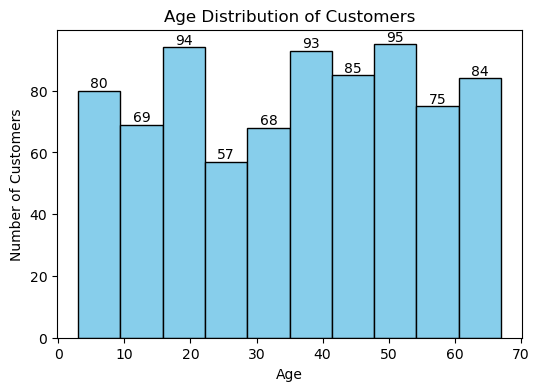

In [22]:
## Visualization Age Distribution (Histogram)
plt.figure(figsize=(6,4))
counts, bins, patches = plt.hist(
    df["age"].dropna(),
    bins=10,
    color="skyblue",
    edgecolor="black"
)
for count, patch in zip(counts, patches):
    plt.text(
        patch.get_x() + patch.get_width() / 2,
        count,
        int(count),
        ha="center",
        va="bottom"
    )
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.title("Age Distribution of Customers")
plt.show()

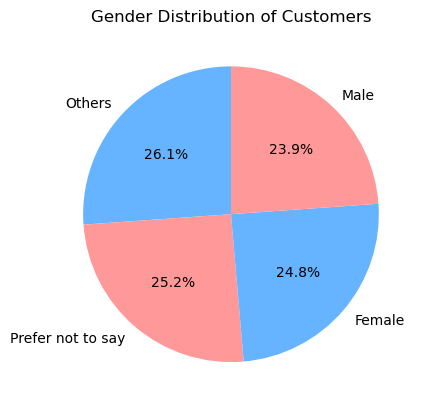

In [21]:
# Visualization Gender Distribution pie chart
df["Gender"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90,
    colors=["#66b3ff","#ff9999"]
)
plt.ylabel("")
plt.title("Gender Distribution of Customers")
plt.show()

### Analyze overall purchase frequency and most popular product categories.

In [26]:
product_counts = df["Purchase_Categories"].value_counts()
product_counts

Purchase_Categories
Clothing and Fashion;others                                                                         40
Clothing and Fashion;Home and Kitchen;others                                                        36
Groceries and Gourmet Food;Beauty and Personal Care;Clothing and Fashion;Home and Kitchen           35
Groceries and Gourmet Food;Home and Kitchen                                                         34
Groceries and Gourmet Food;Beauty and Personal Care                                                 33
Groceries and Gourmet Food;Clothing and Fashion;Home and Kitchen                                    33
Beauty and Personal Care;Clothing and Fashion;Home and Kitchen                                      33
Beauty and Personal Care;Clothing and Fashion;Home and Kitchen;others                               31
others                                                                                              30
Groceries and Gourmet Food;Beauty and Personal Care;o

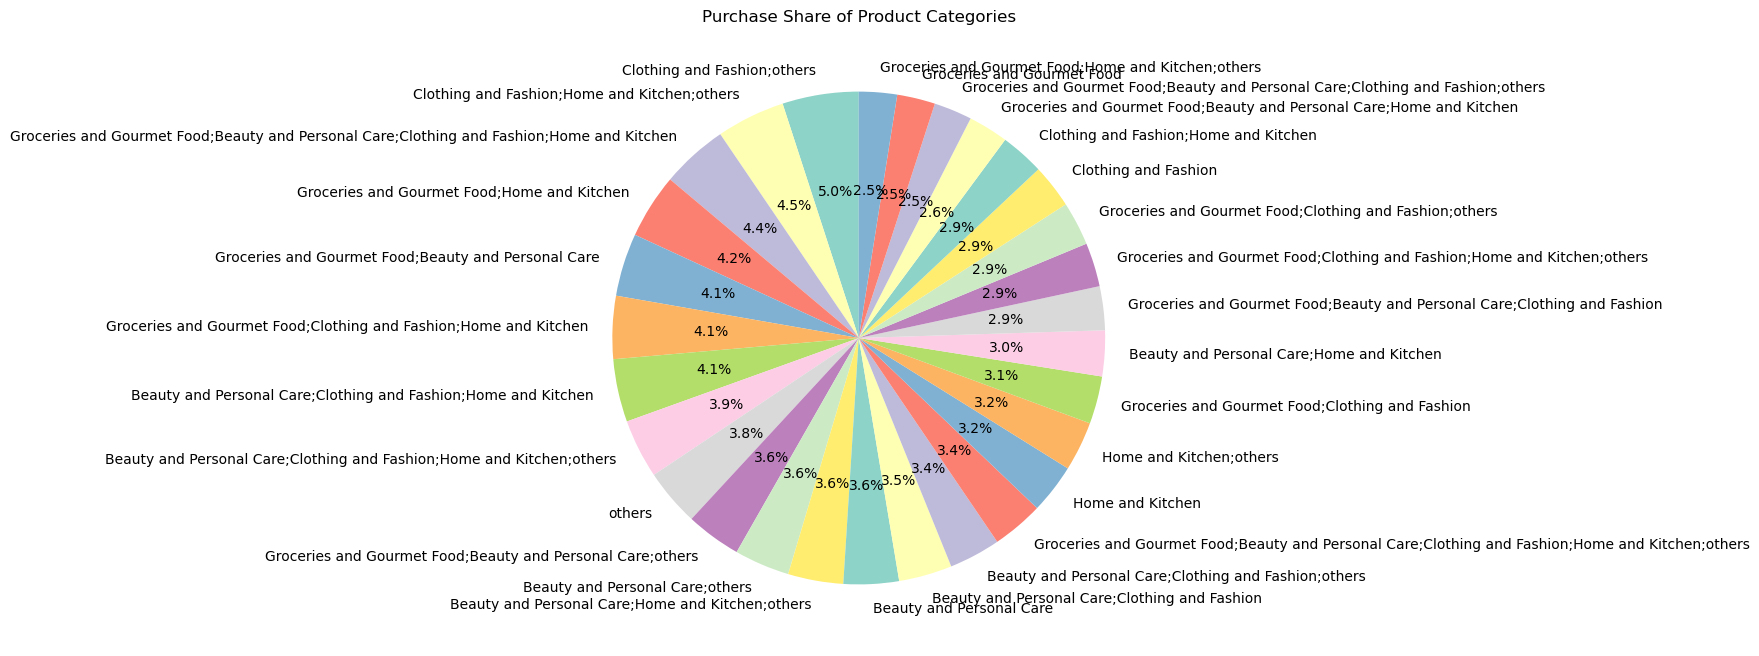

In [31]:
## Visualization Overall purchase frequency
plt.figure(figsize=(16,16))
product_counts.plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90,
    figsize=(8,8),
    colors=sns.color_palette("Set3")
)
plt.ylabel("")
plt.title("Purchase Share of Product Categories")
plt.show()

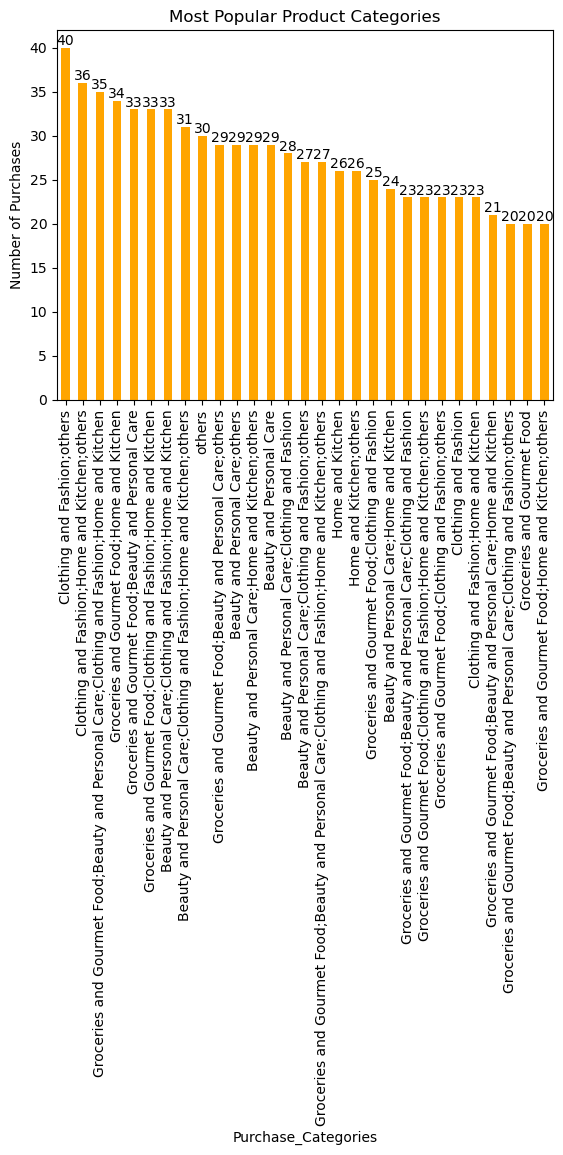

In [32]:
## Visualization most popular product category
ax = df["Purchase_Categories"].value_counts().plot(
    kind="bar",
    title="Most Popular Product Categories",
    color="orange"
)
for p in ax.patches:
    ax.annotate(int(p.get_height()),
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha="center",
                va="bottom")

plt.xlabel("Purchase_Categories")
plt.ylabel("Number of Purchases")
plt.xticks(rotation=90)
plt.show()

### Identify top browsing methods and most common cart abandonment factors.

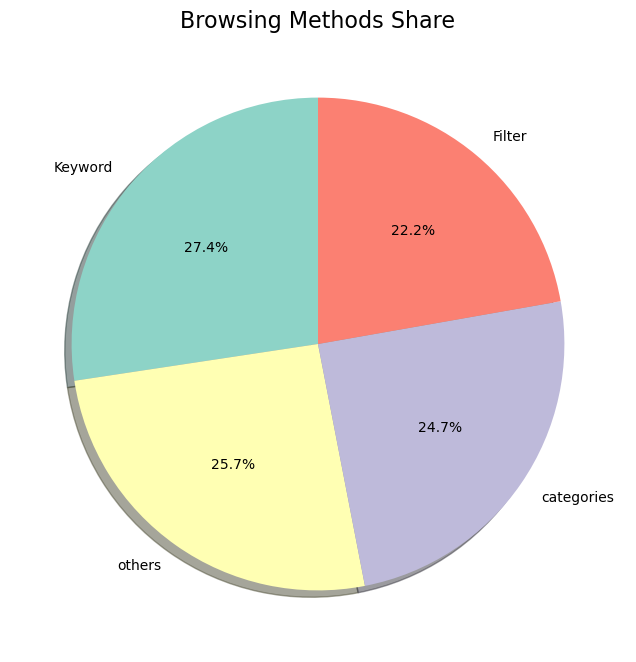

In [33]:
# Visulization of Browsing methods
df["Product_Search_Method"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90,
    figsize=(8,8),
    colors=sns.color_palette("Set3"),
    shadow=True
)
plt.ylabel("")
plt.title("Browsing Methods Share", fontsize=16)
plt.show()

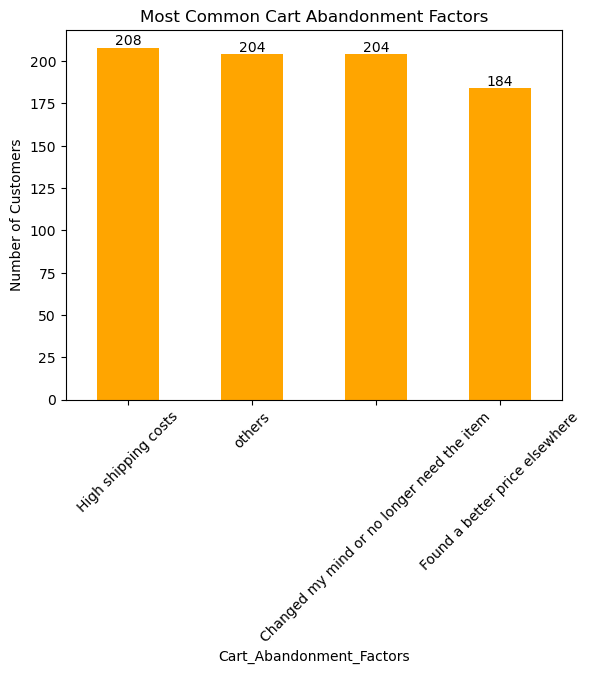

In [38]:
# Visualization for Cart Abandonment
ax = df["Cart_Abandonment_Factors"].value_counts().plot(
    kind="bar",
    title="Most Common Cart Abandonment Factors",
    color="orange"
)

# Add values on top of bars
for p in ax.patches:
    ax.annotate(int(p.get_height()),
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha="center",
                va="bottom")

plt.xlabel("Cart_Abandonment_Factors")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.show()

### Calculate mean and median satisfaction, recommendation helpfulness, and rating accuracy.

In [48]:
df[["Shopping_Satisfaction"]].agg(["mean", "median"])

,Shopping_Satisfaction
mean,2.86625
median,3.00000


In [49]:
df["Recommendation_Helpfulness_numeric"] = df["Recommendation_Helpfulness"].map({"yes": 1, "no": 0})
df[["Recommendation_Helpfulness_numeric"]].agg(["mean", "median"])

,Recommendation_Helpfulness_numeric
mean,NaN
median,NaN


In [51]:
df[["Rating_Accuracy "]].agg(["mean", "median"])

,Rating_Accuracy
mean,3.08625
median,3.00000


### Generate summary statistics and visualizations for key behavioral variables.

In [52]:
# Encoding Categorical Variables
categorical_cols = df.select_dtypes(include=["object"]).columns
encoder = LabelEncoder()
for col in categorical_cols:
    df[col] = encoder.fit_transform(df[col].astype(str))

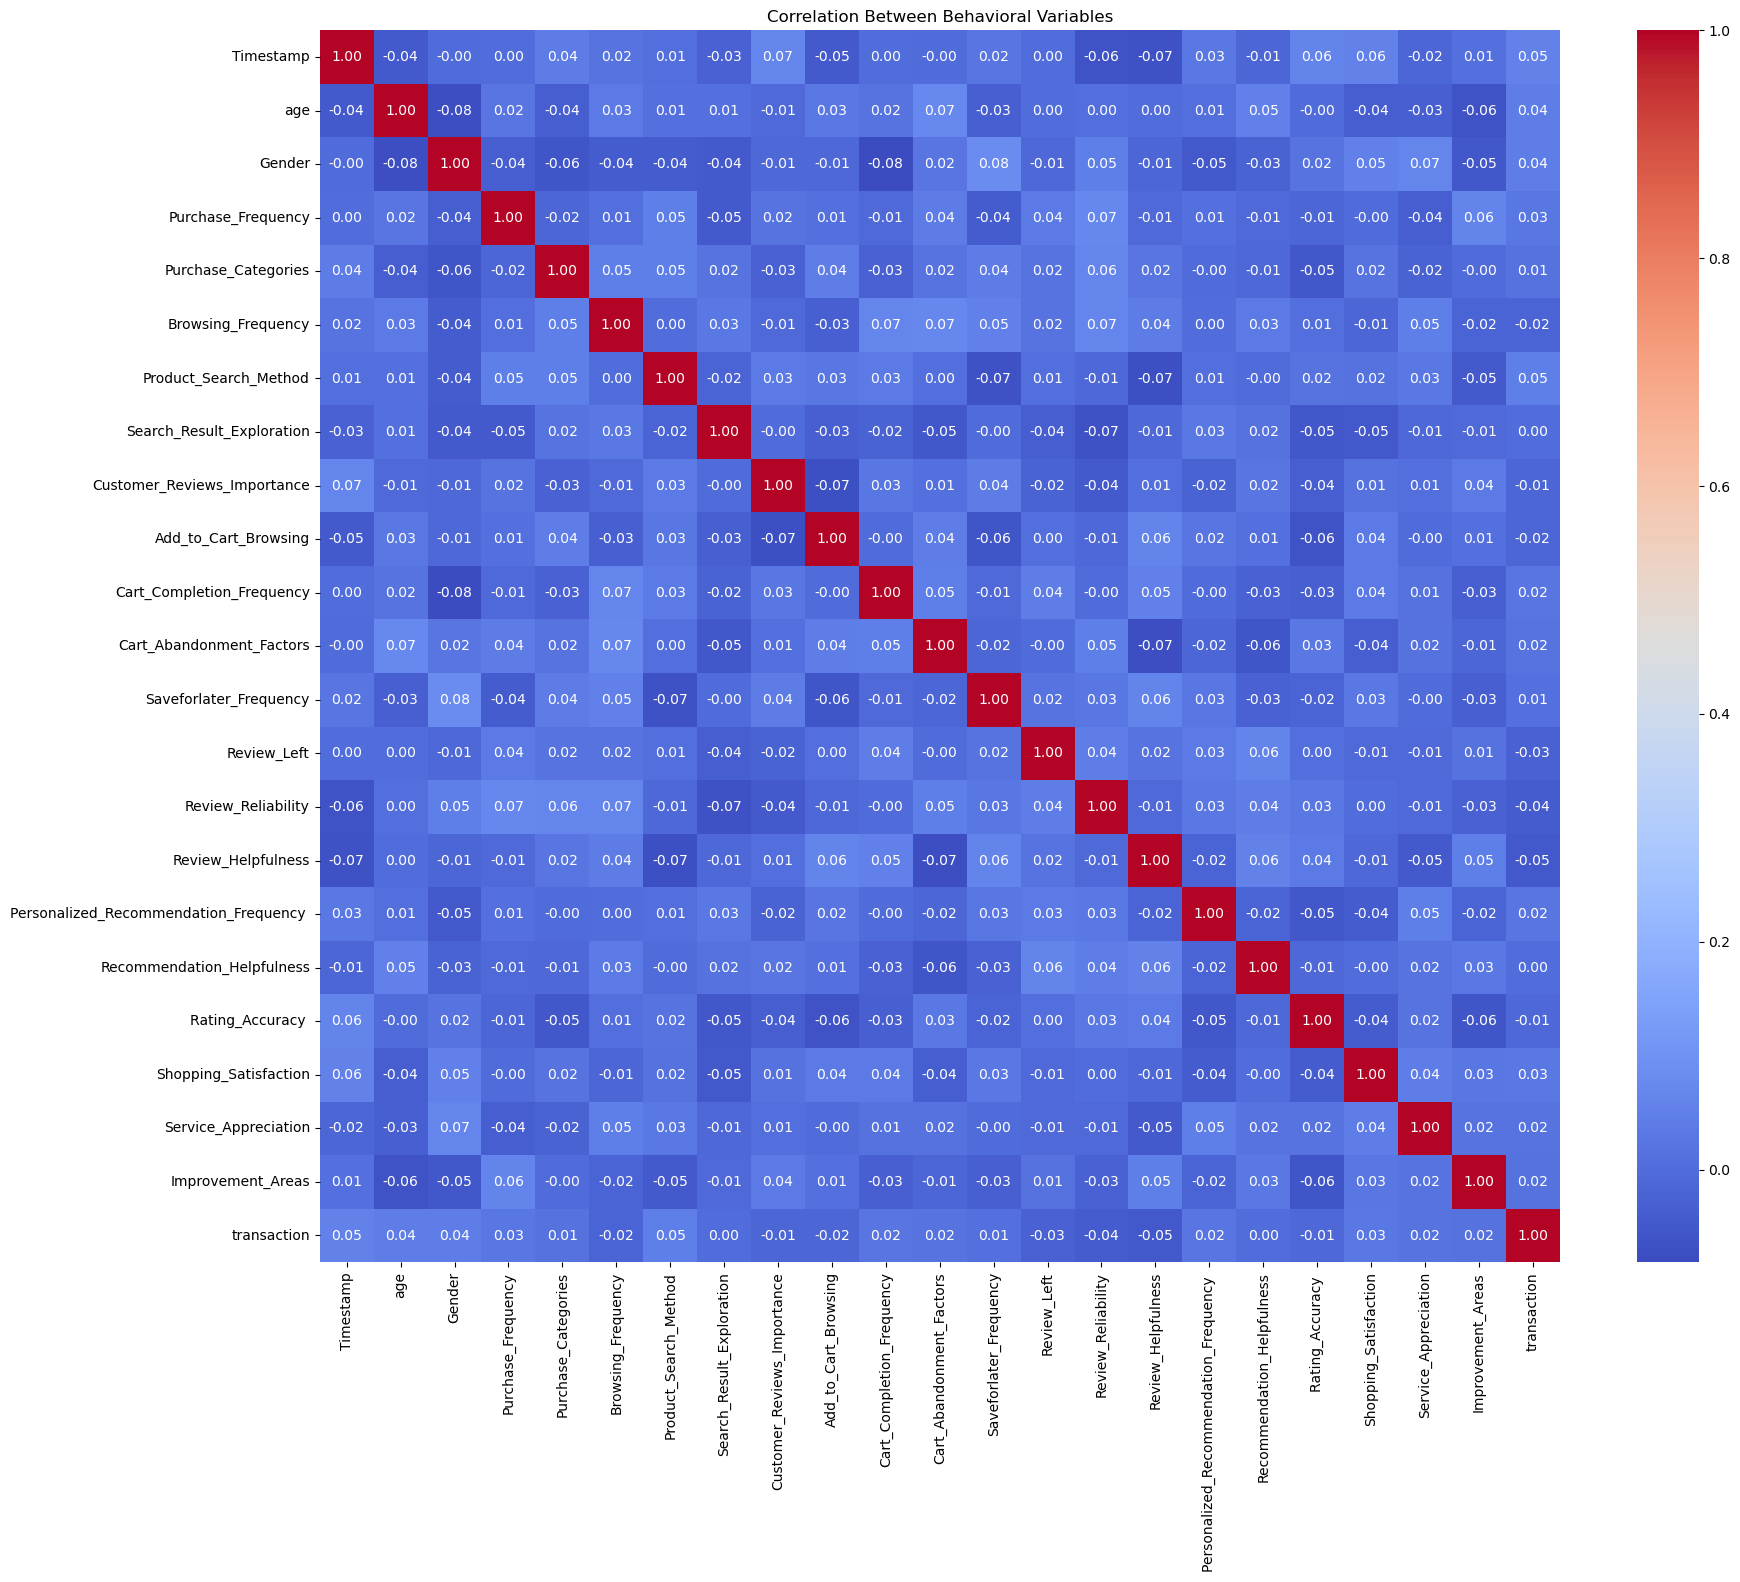

In [54]:
# Behavioral Correlation Heatmap
plt.figure(figsize=(20, 16))
corr = df[categorical_cols].corr()
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Between Behavioral Variables")
plt.show()

# Task 3: Customer Segmentation and Profiling

### Segment customers based on purchase frequency and shopping satisfaction levels.

In [55]:
# Select Only Required Columns
X = df[["Purchase_Frequency", "Shopping_Satisfaction"]]

In [56]:
# Scale the Data
X_scaled = StandardScaler().fit_transform(X)

In [57]:
# Apply K-Means
kmeans = KMeans(n_clusters=3, random_state=42)
df["Segment"] = kmeans.fit_predict(X_scaled)

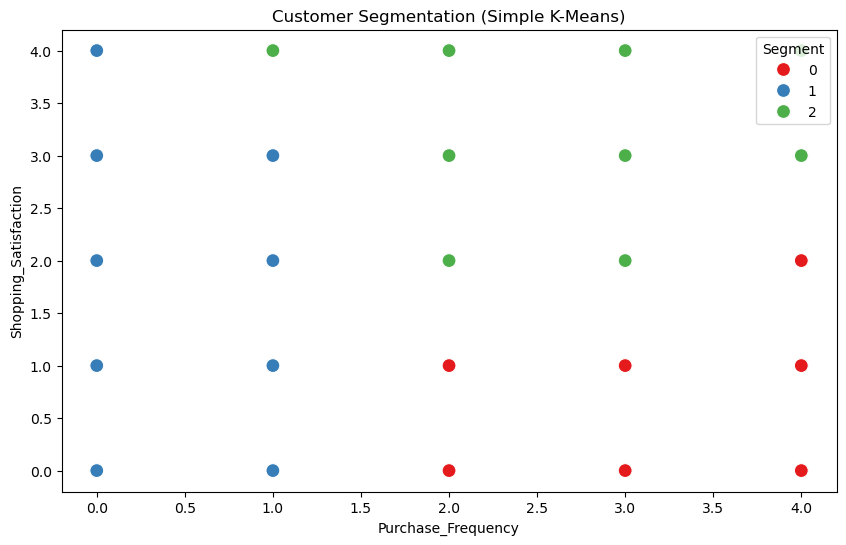

In [58]:
# Visualization
plt.figure(figsize=(10, 6))

sns.scatterplot(
    x="Purchase_Frequency",
    y="Shopping_Satisfaction",
    hue="Segment",
    data=df,
    palette="Set1",
    s=100
)

plt.title("Customer Segmentation (Simple K-Means)")
plt.show()

In [ ]:
0

In [59]:
df.groupby("Segment")[["Purchase_Frequency", "Shopping_Satisfaction"]].mean()

,Purchase_Frequency,Shopping_Satisfaction
Segment,,
0,3.160000,0.653333
1,0.446945,1.623794
2,2.613636,3.185606


## Create profiles such as:
### Frequent Buyers: High purchase frequency, high satisfaction.
### Occasional Shoppers: Medium frequency, moderate satisfaction.
### At-Risk Customers: Low satisfaction or frequent cart abandonment.

In [60]:
features = df[ ["Purchase_Frequency","Shopping_Satisfaction","Cart_Completion_Frequency"]]

In [61]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

In [62]:
kmeans = KMeans(n_clusters=3, random_state=42)
df["Cluster"] = kmeans.fit_predict(X_scaled)

In [63]:
cluster_profile = df.groupby("Cluster")[
    [
        "Purchase_Frequency",
        "Shopping_Satisfaction",
        "Cart_Completion_Frequency"
    ]
].mean()

cluster_profile

,Purchase_Frequency,Shopping_Satisfaction,Cart_Completion_Frequency
Cluster,,,
0,3.380328,1.865574,1.793443
1,0.830189,1.818868,0.864151
2,1.256522,1.921739,3.660870


In [64]:
# segemented based on the clusters and profiles
def label_customer(row):
    if row["Purchase_Frequency"] > cluster_profile["Purchase_Frequency"].mean() and \
       row["Shopping_Satisfaction"] > cluster_profile["Shopping_Satisfaction"].mean():
        return "Frequent Buyers"
    
    elif row["Shopping_Satisfaction"] < cluster_profile["Shopping_Satisfaction"].mean():
        return "At-Risk Customers"
    
    else:
        return "Occasional Shoppers"

df["Customer_Profile"] = df.apply(label_customer, axis=1)

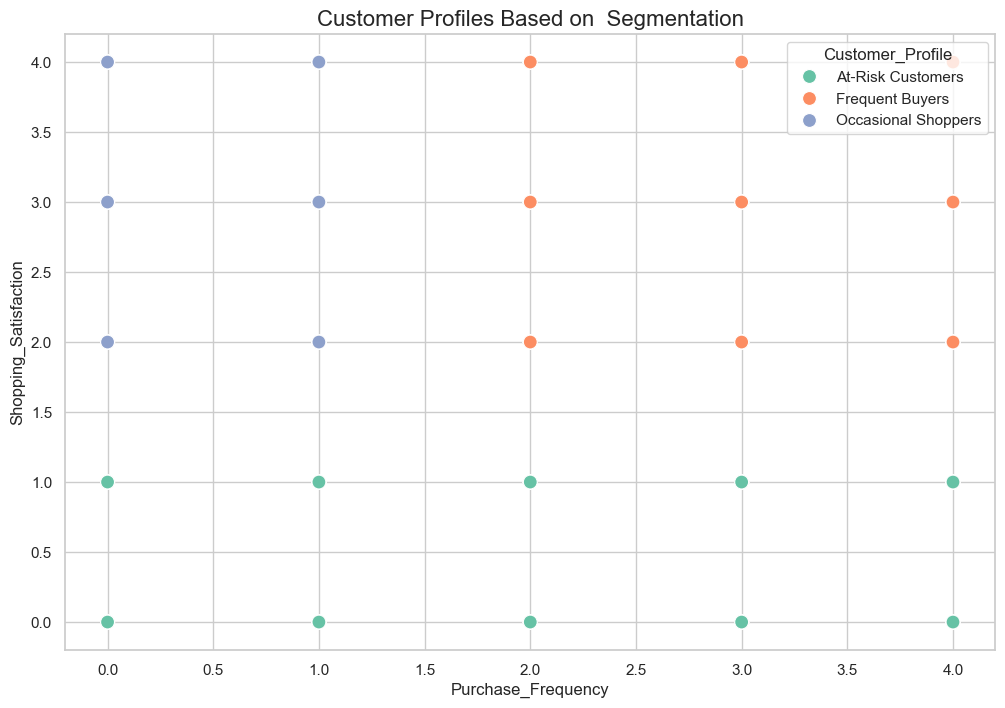

In [97]:
# Visualization
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x="Purchase_Frequency",
    y="Shopping_Satisfaction",
    hue="Customer_Profile",
    data=df,
    palette="Set2",
    s=100
)
plt.title("Customer Profiles Based on  Segmentation", fontsize=16)
plt.show()

In [66]:
df["Customer_Profile"].value_counts()

Customer_Profile
At-Risk Customers      351
Frequent Buyers        259
Occasional Shoppers    190
Name: count, dtype: int64

## Analyze demographic or behavioral differences across these segments.

In [69]:
## segment based on the behavioral columns
segment_summary = df.groupby("Customer_Profile")[
    [
        "age",
        "Purchase_Frequency",
        "Shopping_Satisfaction",
        "Cart_Completion_Frequency",
        "Browsing_Frequency",
        "Personalized_Recommendation_Frequency "
    ]
].mean()

segment_summary

,age,Purchase_Frequency,Shopping_Satisfaction,Cart_Completion_Frequency,Browsing_Frequency,Personalized_Recommendation_Frequency
Customer_Profile,,,,,,
At-Risk Customers,33.182336,1.917379,0.455840,1.940171,1.544160,2.113960
Frequent Buyers,32.092664,2.969112,2.953668,2.065637,1.474903,1.942085
Occasional Shoppers,31.847368,0.515789,2.989474,2.115789,1.594737,1.973684


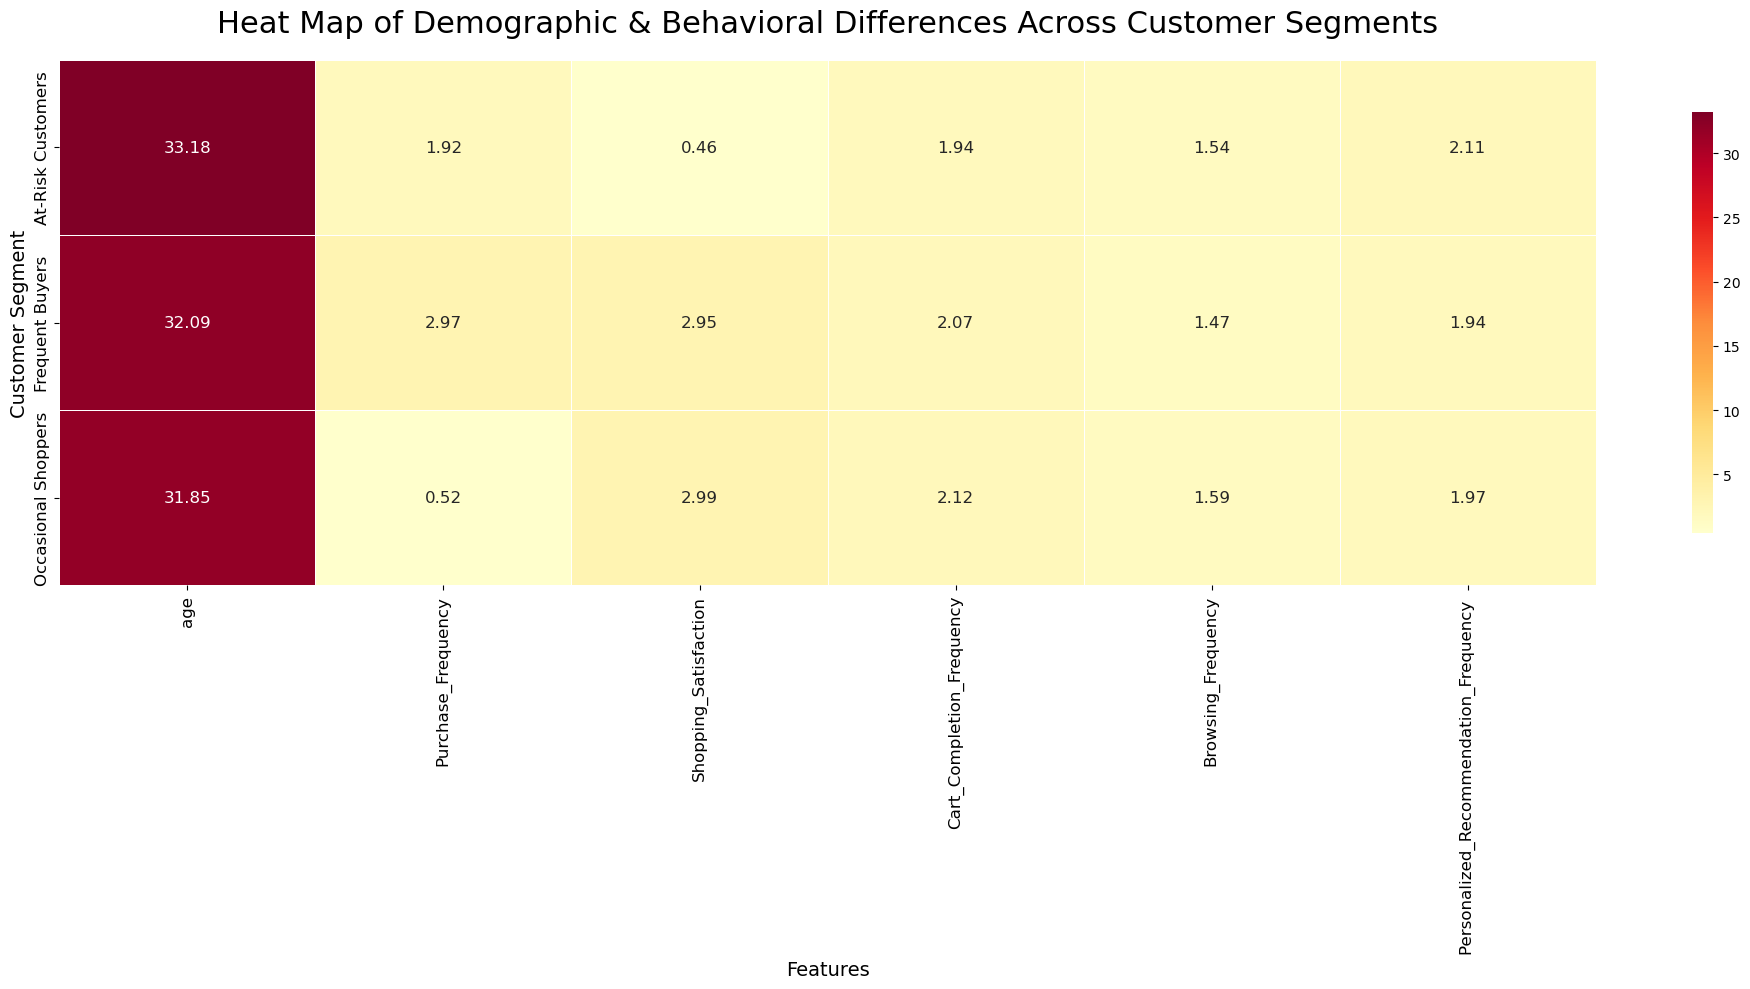

In [70]:
## Visualization heat map
plt.figure(figsize=(20, 10)) 

sns.heatmap(
    segment_summary,
    annot=True,
    fmt=".2f",
    cmap="YlOrRd",
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
    annot_kws={"size": 12}
)
plt.title(
    "Heat Map of Demographic & Behavioral Differences Across Customer Segments",
    fontsize=22,
    pad=20
)

plt.xlabel("Features", fontsize=14)
plt.ylabel("Customer Segment", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
# Insights from the graph
## Age is similar across segments , so demographics don’t strongly differentiate groups.
## Frequent Buyers show the highest purchase frequency and strong engagement.
## Occasional Shoppers have higher shopping satisfaction but low purchase frequency.
## At-Risk Customers have the lowest satisfaction and purchase frequency, indicating churn risk.
## Cart completion, browsing, and recommendation usage are fairly similar across segments, with only minor differences.

# Task 4: Recommendation and Review Insights 


###  Examine the relationship between recommendation helpfulness and shoppingsatisfaction.

In [71]:
# Correlation Analysis
correlation = df["Recommendation_Helpfulness"].corr(
    df["Shopping_Satisfaction"]
)

print("Correlation between Recommendation Helpfulness and Shopping Satisfaction:",
      round(correlation, 3))

Correlation between Recommendation Helpfulness and Shopping Satisfaction: -0.001


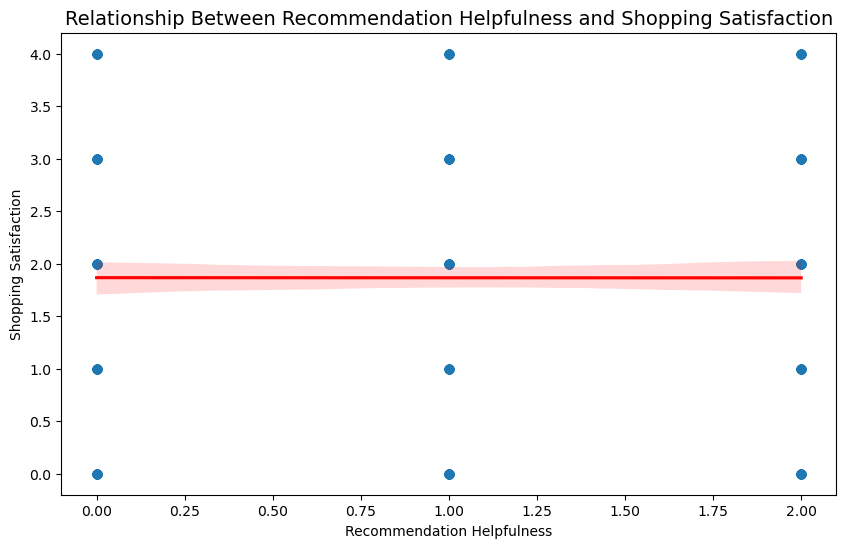

In [72]:
# Scatter Plot with Trend Line
plt.figure(figsize=(10, 6))
sns.regplot(
    x="Recommendation_Helpfulness",
    y="Shopping_Satisfaction",
    data=df,
    scatter_kws={"alpha": 0.6},
    line_kws={"color": "red"}
)
plt.title(
    "Relationship Between Recommendation Helpfulness and Shopping Satisfaction",
    fontsize=14
)
plt.xlabel("Recommendation Helpfulness")
plt.ylabel("Shopping Satisfaction")
plt.show()

In [ ]:
# Insights from the graph
## Very weak relationship: The nearly flat trend line shows little to no correlation between recommendation helpfulness and shopping satisfaction.
## High variability: Satisfaction levels vary widely at each helpfulness level.
## No clear upward trend: Higher recommendation helpfulness does not consistently lead to higher shopping satisfaction.

## Evaluate how review reliability and helpfulness impact overall ratings.


In [101]:
selected = ["Review_Reliability", "Review_Helpfulness" , "Rating_Accuracy" ]

In [102]:
correlation = df_selected.corr()
print("Correlation matrix:\n", correlation)

Correlation matrix:
                     Review_Reliability  Review_Helpfulness  Rating_Accuracy 
Review_Reliability            1.000000           -0.006318          0.029183
Review_Helpfulness           -0.006318            1.000000          0.036210
Rating_Accuracy               0.029183            0.036210          1.000000


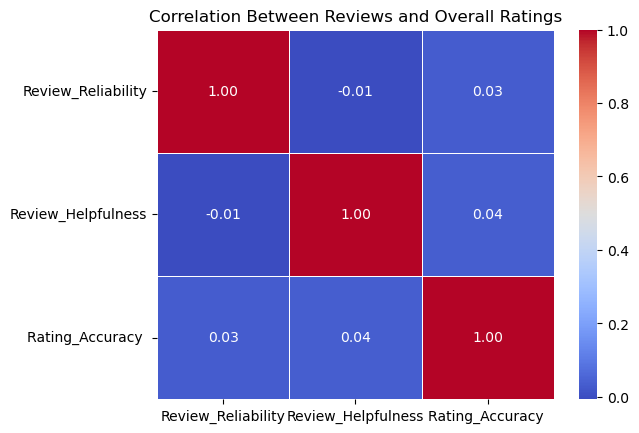

In [76]:
sns.heatmap(correlation, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Between Reviews and Overall Ratings")
plt.show()

In [ ]:
# Insights from the graph
## The graph suggests that Review Reliability, Review Helpfulness, and Rating Accuracy operate largely independently in this dataset. 
## If we are  expecting these factors to reinforce each other, this result indicates:
### Either the constructs are genuinely distinct, or
### The relationship may be non-linear, context-dependent, or influenced by other variables not included here.

### Identify trends in how often customers engage with or trust personalized recommendations.

In [82]:
# Columns of interest
cols = ["Personalized_Recommendation_Frequency ", "Recommendation_Helpfulness"]

In [83]:
# Overall mean & median
overall_summary = df[cols].agg(["mean", "median"])
print("Overall Summary:\n", overall_summary)

Overall Summary:
         Personalized_Recommendation_Frequency   Recommendation_Helpfulness
mean                                     2.025                     0.98625
median                                   2.000                     1.00000


In [84]:
#  segment-wise 
if "Customer_Profile" in df.columns:
    segment_summary = df.groupby("Customer_Profile")[cols].agg(["mean", "median"])
    print("\nSegment-wise Summary:\n", segment_summary)


Segment-wise Summary:
                     Personalized_Recommendation_Frequency          \
                                                      mean median   
Customer_Profile                                                    
At-Risk Customers                                 2.113960    2.0   
Frequent Buyers                                   1.942085    2.0   
Occasional Shoppers                               1.973684    2.0   

                    Recommendation_Helpfulness         
                                          mean median  
Customer_Profile                                       
At-Risk Customers                     0.985755    1.0  
Frequent Buyers                       0.934363    1.0  
Occasional Shoppers                   1.057895    1.0  


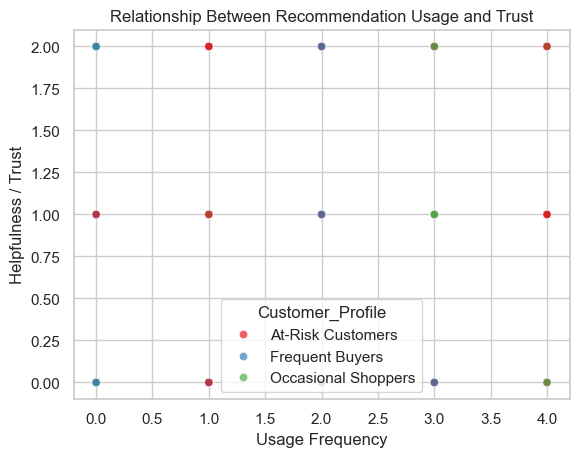

In [90]:
#  visualization
sns.scatterplot(
    x="Personalized_Recommendation_Frequency ",
    y="Recommendation_Helpfulness",
    data=df,
    hue="Customer_Profile" if "Customer_Profile" in df.columns else None,
    palette="Set1",
    alpha=0.7
)
plt.title("Relationship Between Recommendation Usage and Trust")
plt.xlabel("Usage Frequency")
plt.ylabel("Helpfulness / Trust")
plt.show()

### Suggest actionable insights for improving eBay’s recommendation system.

In [ ]:
## Highlight personalized recommendations more prominently on homepage, search results, and product pages.
## Use dynamic notifications or email prompts for users who rarely interact with recommendations.
## Test different formats (carousel, lists, “Recommended for You”) to see what boosts clicks.
## Leverage purchase history, browsing behavior, and wishlists to improve recommendation relevance.
## Implement feedback mechanisms, e.g., “Was this helpful?” to refine recommendation algorithms.
## Use collaborative filtering combined with content-based filtering to surface products that similar users actually buy.
## Prioritize highly rated and helpful products in recommendation lists.
## Incorporate review scores, helpful votes, and verified purchases into recommendation algorithms.
## Highlight why a product is recommended, e.g., “Based on your previous purchases” or “Top-rated by users like you.”

# Task 5: Visualization and Reporting


## Create attractive visualizations (bar charts, heatmaps, pie charts) for:
#### Purchase categories
#### Browsing frequency distribution
#### Satisfaction levels
#### Correlation between recommendation usefulness and satisfaction

## Summarize findings in a clear and visually appealing report format.


C:\Users\DELL\AppData\Local\Temp\ipykernel_12952\585738593.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


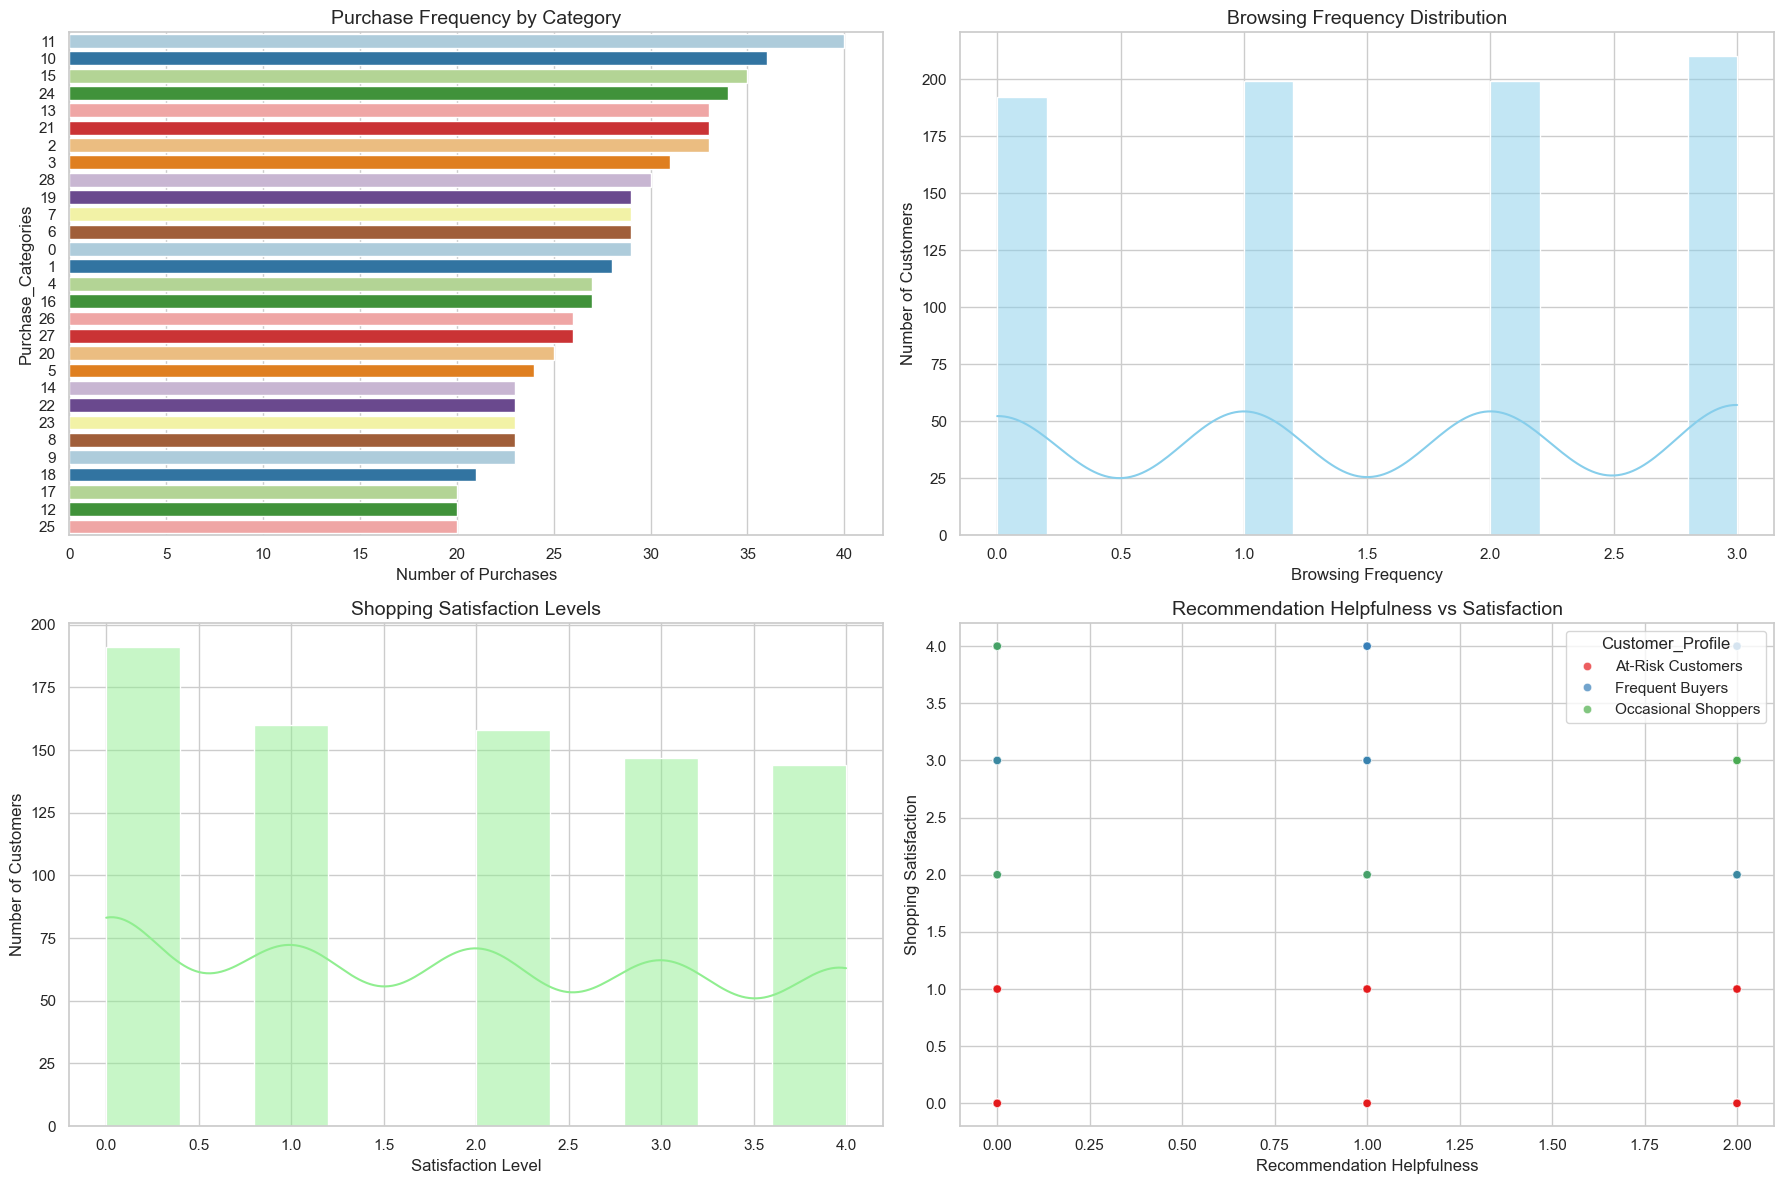

In [95]:
sns.set(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
sns.countplot(
    y="Purchase_Categories",
    data=df,
    order=df["Purchase_Categories"].value_counts().index,
    palette="Paired",
    ax=axes[0,0]
)
axes[0,0].set_title("Purchase Frequency by Category", fontsize=14)
axes[0,0].set_xlabel("Number of Purchases")
axes[0,0].set_ylabel("Purchase_Categories")

sns.histplot(df["Browsing_Frequency"], bins=15, kde=True, color="skyblue", ax=axes[0,1])
axes[0,1].set_title("Browsing Frequency Distribution", fontsize=14)
axes[0,1].set_xlabel("Browsing Frequency")
axes[0,1].set_ylabel("Number of Customers")

sns.histplot(df["Shopping_Satisfaction"], bins=10, kde=True, color="lightgreen", ax=axes[1,0])
axes[1,0].set_title("Shopping Satisfaction Levels", fontsize=14)
axes[1,0].set_xlabel("Satisfaction Level")
axes[1,0].set_ylabel("Number of Customers")

sns.scatterplot(
    x="Recommendation_Helpfulness",
    y="Shopping_Satisfaction",
    data=df,
    hue="Customer_Profile" if "Customer_Profile" in df.columns else None,
    palette="Set1",
    alpha=0.7,
    ax=axes[1,1]
)
axes[1,1].set_title("Recommendation Helpfulness vs Satisfaction", fontsize=14)
axes[1,1].set_xlabel("Recommendation Helpfulness")
axes[1,1].set_ylabel("Shopping Satisfaction")

plt.tight_layout()
plt.show()

In [ ]:
## Optimize Recommendation Placement: Increase visibility for low-engagement users.
## Segment-Based Personalization: Frequent Buyers, Occasional Shoppers, At-Risk Customers.
## Focus on Trust & Helpfulness: Show highly rated, relevant items.
## Promote Underperforming Categories: Target marketing campaigns for less purchased products.
## Monitor Satisfaction: Track how recommendation changes impact overall satisfaction.

#### Highlight what drives customer transaction behavior and financial risk.

In [ ]:
## Risk Factors
## Low satisfaction-High chance of churn or cart abandonment
## Infrequent purchasing-Unpredictable revenue streams
## Low recommendation trust-Missed upselling / cross-selling opportunities
## High cart abandonment-Lost potential transactions
## Limited category engagement-Over-reliance on few categories can affect revenue stability

#### Discuss data-backed recommendations for customer engagement or monitoring.

In [ ]:
## Segment-Based Personalization: Tailor recommendations for Frequent Buyers, Occasional Shoppers, and At-Risk Customers.
## Optimize Recommendation System: Use purchase and browsing data to increase relevance; add feedback loops.
## Targeted Communication: Send personalized offers or reminders to low-engagement customers.
## Promote Underperforming Categories: Encourage exploration to balance revenue.
## Track Key Metrics: Monitor purchase frequency, satisfaction, and recommendation trust.
## Behavioral Analytics: Detect changes in browsing vs purchase patterns to identify at-risk users.
## Financial Risk Alerts: Flag low satisfaction, high cart abandonment, or infrequent purchases for intervention.